# Software Development Lifecycle using Lang-Graph

In [18]:
import sys
print(sys.executable)

c:\Github\SDLC-using-Lang-Graph\env\Scripts\python.exe


In [19]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [20]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [22]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5
)

In [28]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [29]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "1"}}

In [30]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [36]:
from tools.designer import create, append, rewrite, read_design

In [37]:
tools = [create, append, rewrite, read_design]

In [38]:
designer = llm.bind_tools(tools = tools)

def desiging_agent(state:State):
    response = designer.invoke(state["messages"])
    return {"messages": [response]}

In [39]:
graph_builder = StateGraph(State)

graph_builder.add_node("Designer", desiging_agent)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_edge(START, "Designer")
graph_builder.add_conditional_edges(
    "Designer",
    tools_condition
)
graph_builder.add_edge("tools", "Designer")

graph = graph_builder.compile(checkpointer=memory)

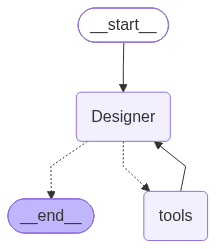

In [40]:
graph

In [41]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="create the design for a study application, it is a mobile app, it uses " \
    "timing functions like stopwatch tracks goals of the user. The app should be built in flutter " \
    "and should have minimalistic  design and the data of  the user should also be stored in terms of" \
    "hours studied, tests taken et  cetra"),
    
]},config=config
)

In [42]:
for m  in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

create the design for a study application, it is a mobile app, it uses timing functions like stopwatch tracks goals of the user. The app should be built in flutter and should have minimalistic  design and the data of  the user should also be stored in terms ofhours studied, tests taken et  cetra
================================== Ai Message ==================================
Tool Calls:
  create (call_g2Yix1uo6RccZZL82vyTN45u)
 Call ID: call_g2Yix1uo6RccZZL82vyTN45u
  Args:
    text: The study application will be a mobile app built using Flutter, ensuring cross-platform compatibility for both iOS and Android devices. The app will feature a minimalistic design focused on ease of use and clean aesthetics. Core functionalities include timing functions such as a stopwatch to track study sessions and goal tracking to monitor user progress. The app will store user data including hours studied, tests taken, and 

In [22]:
from langchain_core.messages import HumanMessage

graph.invoke({"messages" : [
    HumanMessage(content="summarize plan.md and suggest any improvments."),
    
]},config=config
)

{'messages': [HumanMessage(content='rewrite plan.md and make me a study planning  app nd it should contain goals stopwatch and usual study app features', additional_kwargs={}, response_metadata={}, id='f8b71a0f-b0b6-4f0f-ad87-1038cd557708'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 369, 'prompt_tokens': 525, 'total_tokens': 894, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4719245614', 'id': 'chatcmpl-E5Pr6xKWwcgdXsRwJssEC7tjFRNON', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f97e3-dc8d-7f12-9215-29740ee6cfae-0', tool_calls=[{'name': 'rewrite', 'args': {'query': 'Project Plan: Study Pl